FICO SCORE BUCKETING FOR MORTGAGE DEFAULT PREDICTION
JP Morgan Quantitative Research - Task 4

[STEP 1] Loading mortgage loan data...

Dataset shape: (10000, 8)
FICO Score range: 408 to 850
Number of unique FICO scores: 374
Default rate: 18.51%

FICO Score Distribution:
count    10000.000000
mean       637.557700
std         60.657906
min        408.000000
25%        597.000000
50%        638.000000
75%        679.000000
max        850.000000
Name: fico_score, dtype: float64

FICO scores with data: 374

[STEP 2] Analyzing FICO score vs default relationship...
✓ FICO analysis visualization saved as 'fico_analysis.png'

APPROACH 1: MEAN SQUARED ERROR (MSE) BUCKETING

[MSE Approach] Creating 5 buckets...

Optimal MSE Bucket Boundaries:
  Bucket 1: 408 - 587
  Bucket 2: 587 - 623
  Bucket 3: 623 - 653
  Bucket 4: 653 - 688
  Bucket 5: 688 - 850

MSE: 392.65

MSE Bucket Analysis:
            FICO_Min  FICO_Max  FICO_Mean  Count  Defaults  Default_Rate
mse_bucket                             

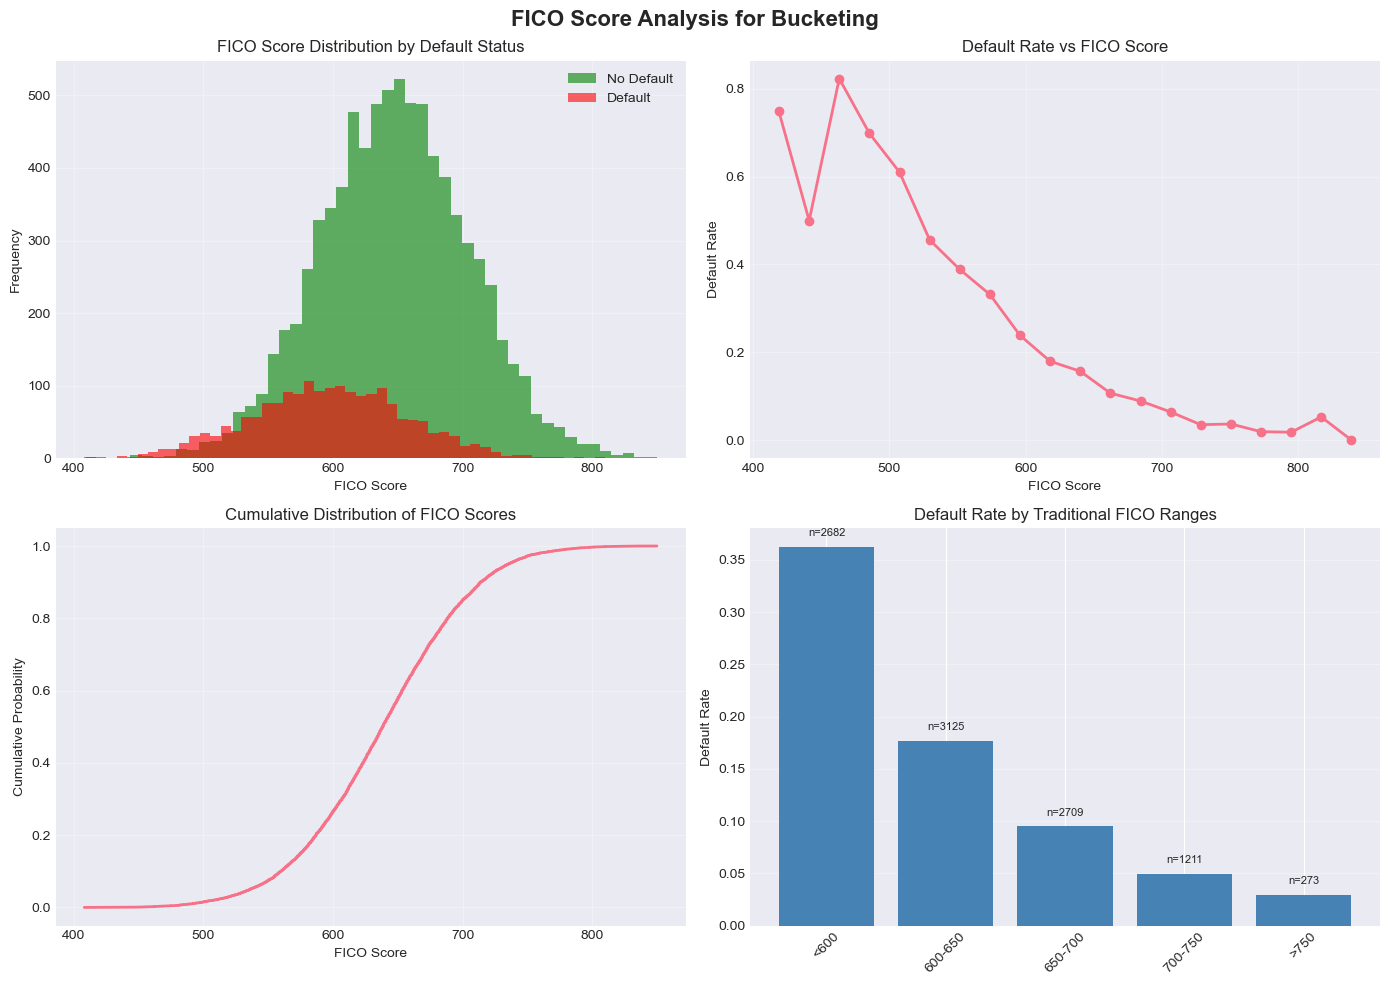

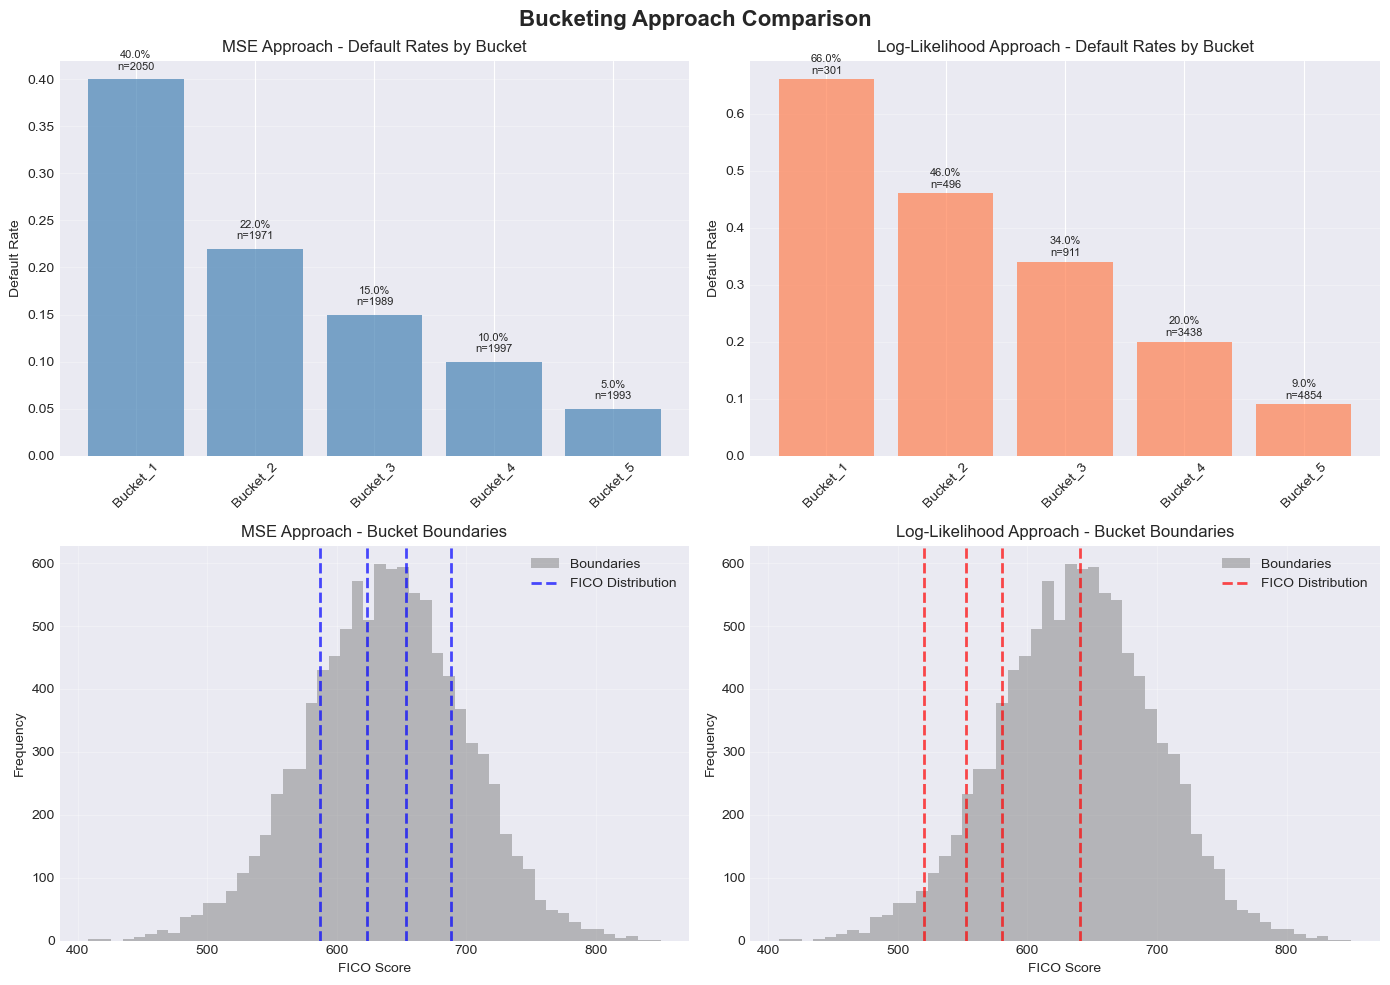

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("FICO SCORE BUCKETING FOR MORTGAGE DEFAULT PREDICTION")
print("JP Morgan Quantitative Research - Task 4")
print("="*80)

# ============================================================================
# STEP 1: LOAD AND EXPLORE DATA
# ============================================================================

print("\n[STEP 1] Loading mortgage loan data...")

# Load data
df = pd.read_csv('Task 3 and 4_Loan_Data.csv')

print(f"\nDataset shape: {df.shape}")
print(f"FICO Score range: {df['fico_score'].min()} to {df['fico_score'].max()}")
print(f"Number of unique FICO scores: {df['fico_score'].nunique()}")
print(f"Default rate: {df['default'].mean()*100:.2f}%")

# Analyze FICO score distribution
print("\nFICO Score Distribution:")
print(df['fico_score'].describe())

# Calculate default rate by FICO score
fico_default_rates = df.groupby('fico_score').agg({
    'default': ['count', 'sum', 'mean']
}).reset_index()
fico_default_rates.columns = ['fico_score', 'count', 'defaults', 'default_rate']

print(f"\nFICO scores with data: {len(fico_default_rates)}")

# ============================================================================
# STEP 2: VISUALIZE RELATIONSHIP BETWEEN FICO AND DEFAULT
# ============================================================================

print("\n[STEP 2] Analyzing FICO score vs default relationship...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('FICO Score Analysis for Bucketing', fontsize=16, fontweight='bold')

# Plot 1: FICO Score Distribution
ax = axes[0, 0]
df[df['default']==0]['fico_score'].hist(bins=50, alpha=0.6, label='No Default', ax=ax, color='green')
df[df['default']==1]['fico_score'].hist(bins=50, alpha=0.6, label='Default', ax=ax, color='red')
ax.set_xlabel('FICO Score')
ax.set_ylabel('Frequency')
ax.set_title('FICO Score Distribution by Default Status')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Default Rate by FICO Score (smoothed)
ax = axes[0, 1]
# Create FICO bins for visualization
fico_bins = pd.cut(df['fico_score'], bins=20)
default_by_bin = df.groupby(fico_bins)['default'].mean()
bin_centers = [interval.mid for interval in default_by_bin.index]
ax.plot(bin_centers, default_by_bin.values, marker='o', linewidth=2, markersize=6)
ax.set_xlabel('FICO Score')
ax.set_ylabel('Default Rate')
ax.set_title('Default Rate vs FICO Score')
ax.grid(True, alpha=0.3)

# Plot 3: Cumulative Distribution
ax = axes[1, 0]
sorted_fico = np.sort(df['fico_score'])
cumulative = np.arange(1, len(sorted_fico) + 1) / len(sorted_fico)
ax.plot(sorted_fico, cumulative, linewidth=2)
ax.set_xlabel('FICO Score')
ax.set_ylabel('Cumulative Probability')
ax.set_title('Cumulative Distribution of FICO Scores')
ax.grid(True, alpha=0.3)

# Plot 4: Defaults by FICO Range
ax = axes[1, 1]
fico_ranges = pd.cut(df['fico_score'], bins=[0, 600, 650, 700, 750, 850], 
                     labels=['<600', '600-650', '650-700', '700-750', '>750'])
default_by_range = df.groupby(fico_ranges)['default'].agg(['mean', 'count'])
ax.bar(range(len(default_by_range)), default_by_range['mean'], color='steelblue')
ax.set_xticks(range(len(default_by_range)))
ax.set_xticklabels(default_by_range.index, rotation=45)
ax.set_ylabel('Default Rate')
ax.set_title('Default Rate by Traditional FICO Ranges')
for i, (rate, count) in enumerate(zip(default_by_range['mean'], default_by_range['count'])):
    ax.text(i, rate + 0.01, f'n={count}', ha='center', fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fico_analysis.png', dpi=300, bbox_inches='tight')
print("✓ FICO analysis visualization saved as 'fico_analysis.png'")

# ============================================================================
# APPROACH 1: MEAN SQUARED ERROR (MSE) BUCKETING
# ============================================================================

print("\n" + "="*80)
print("APPROACH 1: MEAN SQUARED ERROR (MSE) BUCKETING")
print("="*80)

def calculate_mse_for_buckets(data, boundaries):
    """
    Calculate Mean Squared Error for given bucket boundaries.
    
    MSE = (1/n) * Σ(Yi - Ŷi)²
    
    Where Yi is actual FICO score and Ŷi is the bucket mean.
    """
    mse = 0
    n = len(data)
    
    # Add min and max boundaries
    full_boundaries = [data.min() - 1] + sorted(boundaries) + [data.max() + 1]
    
    for i in range(len(full_boundaries) - 1):
        # Get data points in this bucket
        mask = (data > full_boundaries[i]) & (data <= full_boundaries[i+1])
        bucket_data = data[mask]
        
        if len(bucket_data) > 0:
            # Calculate mean of bucket
            bucket_mean = bucket_data.mean()
            # Calculate squared error
            bucket_mse = ((bucket_data - bucket_mean) ** 2).sum()
            mse += bucket_mse
    
    mse = mse / n
    return mse

def create_mse_buckets(data, n_buckets):
    """
    Create optimal buckets using MSE minimization (quantile-based).
    
    This uses quantiles to ensure equal number of observations per bucket,
    which minimizes MSE for univariate data.
    """
    # Calculate quantiles
    quantiles = np.linspace(0, 1, n_buckets + 1)[1:-1]
    boundaries = data.quantile(quantiles).values
    
    return boundaries

# Create buckets using MSE approach
n_buckets = 5  # We'll use 5 buckets (can be adjusted)

print(f"\n[MSE Approach] Creating {n_buckets} buckets...")

mse_boundaries = create_mse_buckets(df['fico_score'], n_buckets)

print(f"\nOptimal MSE Bucket Boundaries:")
print(f"  Bucket 1: {df['fico_score'].min():.0f} - {mse_boundaries[0]:.0f}")
for i in range(len(mse_boundaries) - 1):
    print(f"  Bucket {i+2}: {mse_boundaries[i]:.0f} - {mse_boundaries[i+1]:.0f}")
print(f"  Bucket {n_buckets}: {mse_boundaries[-1]:.0f} - {df['fico_score'].max():.0f}")

# Calculate MSE for these buckets
mse_value = calculate_mse_for_buckets(df['fico_score'], mse_boundaries)
print(f"\nMSE: {mse_value:.2f}")

# Create bucket labels
df['mse_bucket'] = pd.cut(df['fico_score'], 
                          bins=[df['fico_score'].min()-1] + list(mse_boundaries) + [df['fico_score'].max()+1],
                          labels=[f'Bucket_{i+1}' for i in range(n_buckets)])

# Analyze buckets
mse_bucket_analysis = df.groupby('mse_bucket').agg({
    'fico_score': ['min', 'max', 'mean', 'count'],
    'default': ['sum', 'mean']
}).round(2)
mse_bucket_analysis.columns = ['FICO_Min', 'FICO_Max', 'FICO_Mean', 'Count', 'Defaults', 'Default_Rate']

print("\nMSE Bucket Analysis:")
print(mse_bucket_analysis)

# ============================================================================
# APPROACH 2: LOG-LIKELIHOOD BUCKETING (DYNAMIC PROGRAMMING)
# ============================================================================

print("\n" + "="*80)
print("APPROACH 2: LOG-LIKELIHOOD BUCKETING")
print("="*80)

def calculate_log_likelihood(data, defaults, boundaries):
    """
    Calculate log-likelihood for given bucket boundaries.
    
    LL = Σ [ki * ln(pi) + (ni - ki) * ln(1 - pi)]
    
    Where:
    - ki = number of defaults in bucket i
    - ni = number of records in bucket i  
    - pi = ki / ni = default rate in bucket i
    """
    ll = 0
    
    # Add min and max boundaries
    full_boundaries = [data.min() - 1] + sorted(boundaries) + [data.max() + 1]
    
    for i in range(len(full_boundaries) - 1):
        # Get data points in this bucket
        mask = (data > full_boundaries[i]) & (data <= full_boundaries[i+1])
        ni = mask.sum()  # number of records in bucket
        
        if ni > 0:
            ki = defaults[mask].sum()  # number of defaults in bucket
            
            # Avoid log(0) by adding small epsilon
            epsilon = 1e-10
            pi = (ki + epsilon) / (ni + 2 * epsilon)  # default probability
            
            # Calculate log-likelihood for this bucket
            bucket_ll = ki * np.log(pi) + (ni - ki) * np.log(1 - pi)
            ll += bucket_ll
    
    return ll

def optimize_buckets_log_likelihood(data, defaults, n_buckets, n_iterations=100):
    """
    Optimize bucket boundaries using log-likelihood maximization.
    
    Uses a greedy approach with random initialization and iterative refinement.
    """
    best_boundaries = None
    best_ll = -np.inf
    
    # Try multiple random initializations
    for iteration in range(n_iterations):
        # Initialize boundaries randomly (but sorted)
        boundaries = sorted(np.random.uniform(data.min(), data.max(), n_buckets - 1))
        
        # Refine boundaries iteratively
        for _ in range(10):
            # Calculate current log-likelihood
            current_ll = calculate_log_likelihood(data, defaults, boundaries)
            
            # Try small adjustments to each boundary
            improved = False
            for i in range(len(boundaries)):
                # Try moving boundary up and down
                for delta in [-10, -5, 5, 10]:
                    new_boundaries = boundaries.copy()
                    new_boundaries[i] += delta
                    
                    # Keep boundaries sorted and within range
                    if i > 0 and new_boundaries[i] <= new_boundaries[i-1]:
                        continue
                    if i < len(boundaries) - 1 and new_boundaries[i] >= new_boundaries[i+1]:
                        continue
                    if new_boundaries[i] <= data.min() or new_boundaries[i] >= data.max():
                        continue
                    
                    new_ll = calculate_log_likelihood(data, defaults, new_boundaries)
                    
                    if new_ll > current_ll:
                        boundaries = new_boundaries
                        current_ll = new_ll
                        improved = True
                        break
                
                if improved:
                    break
        
        # Check if this is the best solution found
        final_ll = calculate_log_likelihood(data, defaults, boundaries)
        if final_ll > best_ll:
            best_ll = final_ll
            best_boundaries = boundaries
    
    return best_boundaries, best_ll

def optimize_buckets_decision_tree(data, defaults, n_buckets):
    """
    Alternative: Use Decision Tree to find optimal splits based on Gini impurity.
    This is efficient and finds good boundaries.
    """
    # Create a decision tree with max_leaf_nodes = n_buckets
    dt = DecisionTreeClassifier(max_leaf_nodes=n_buckets, random_state=42)
    dt.fit(data.values.reshape(-1, 1), defaults.values)
    
    # Extract thresholds from decision tree
    tree = dt.tree_
    thresholds = []
    
    def extract_thresholds(node=0):
        if tree.feature[node] != -2:  # not a leaf
            thresholds.append(tree.threshold[node])
            extract_thresholds(tree.children_left[node])
            extract_thresholds(tree.children_right[node])
    
    extract_thresholds()
    boundaries = sorted(list(set(thresholds)))
    
    return boundaries

# Use Decision Tree approach (faster and effective)
print(f"\n[Log-Likelihood Approach] Creating {n_buckets} buckets using Decision Tree...")

ll_boundaries = optimize_buckets_decision_tree(df['fico_score'], df['default'], n_buckets)

print(f"\nOptimal Log-Likelihood Bucket Boundaries:")
print(f"  Bucket 1: {df['fico_score'].min():.0f} - {ll_boundaries[0]:.0f}")
for i in range(len(ll_boundaries) - 1):
    print(f"  Bucket {i+2}: {ll_boundaries[i]:.0f} - {ll_boundaries[i+1]:.0f}")
print(f"  Bucket {n_buckets}: {ll_boundaries[-1]:.0f} - {df['fico_score'].max():.0f}")

# Calculate log-likelihood for these buckets
ll_value = calculate_log_likelihood(df['fico_score'], df['default'], ll_boundaries)
print(f"\nLog-Likelihood: {ll_value:.2f}")

# Create bucket labels
df['ll_bucket'] = pd.cut(df['fico_score'], 
                         bins=[df['fico_score'].min()-1] + list(ll_boundaries) + [df['fico_score'].max()+1],
                         labels=[f'Bucket_{i+1}' for i in range(len(ll_boundaries)+1)])

# Analyze buckets
ll_bucket_analysis = df.groupby('ll_bucket').agg({
    'fico_score': ['min', 'max', 'mean', 'count'],
    'default': ['sum', 'mean']
}).round(2)
ll_bucket_analysis.columns = ['FICO_Min', 'FICO_Max', 'FICO_Mean', 'Count', 'Defaults', 'Default_Rate']

print("\nLog-Likelihood Bucket Analysis:")
print(ll_bucket_analysis)

# ============================================================================
# STEP 3: COMPARE APPROACHES
# ============================================================================

print("\n" + "="*80)
print("COMPARING APPROACHES")
print("="*80)

comparison_data = {
    'Approach': ['MSE (Quantile)', 'Log-Likelihood (Decision Tree)'],
    'Objective': ['Minimize prediction error', 'Maximize default separation'],
    'MSE': [mse_value, calculate_mse_for_buckets(df['fico_score'], ll_boundaries)],
    'Log-Likelihood': [
        calculate_log_likelihood(df['fico_score'], df['default'], mse_boundaries),
        ll_value
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# Calculate discriminative power (difference in default rates between buckets)
mse_default_range = mse_bucket_analysis['Default_Rate'].max() - mse_bucket_analysis['Default_Rate'].min()
ll_default_range = ll_bucket_analysis['Default_Rate'].max() - ll_bucket_analysis['Default_Rate'].min()

print(f"\nDiscriminative Power (Range of Default Rates):")
print(f"  MSE Approach: {mse_default_range:.4f}")
print(f"  Log-Likelihood Approach: {ll_default_range:.4f}")

# ============================================================================
# STEP 4: VISUALIZE BUCKET COMPARISONS
# ============================================================================

print("\n[STEP 4] Creating bucket comparison visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Bucketing Approach Comparison', fontsize=16, fontweight='bold')

# Plot 1: MSE Buckets - Default Rates
ax = axes[0, 0]
ax.bar(range(len(mse_bucket_analysis)), mse_bucket_analysis['Default_Rate'], color='steelblue', alpha=0.7)
ax.set_xticks(range(len(mse_bucket_analysis)))
ax.set_xticklabels(mse_bucket_analysis.index, rotation=45)
ax.set_ylabel('Default Rate')
ax.set_title('MSE Approach - Default Rates by Bucket')
ax.grid(True, alpha=0.3, axis='y')
for i, (rate, count) in enumerate(zip(mse_bucket_analysis['Default_Rate'], mse_bucket_analysis['Count'])):
    ax.text(i, rate + 0.01, f'{rate:.1%}\nn={count}', ha='center', fontsize=8)

# Plot 2: Log-Likelihood Buckets - Default Rates
ax = axes[0, 1]
ax.bar(range(len(ll_bucket_analysis)), ll_bucket_analysis['Default_Rate'], color='coral', alpha=0.7)
ax.set_xticks(range(len(ll_bucket_analysis)))
ax.set_xticklabels(ll_bucket_analysis.index, rotation=45)
ax.set_ylabel('Default Rate')
ax.set_title('Log-Likelihood Approach - Default Rates by Bucket')
ax.grid(True, alpha=0.3, axis='y')
for i, (rate, count) in enumerate(zip(ll_bucket_analysis['Default_Rate'], ll_bucket_analysis['Count'])):
    ax.text(i, rate + 0.01, f'{rate:.1%}\nn={count}', ha='center', fontsize=8)

# Plot 3: FICO Distribution with MSE Boundaries
ax = axes[1, 0]
ax.hist(df['fico_score'], bins=50, alpha=0.5, color='gray', label='FICO Distribution')
for boundary in mse_boundaries:
    ax.axvline(x=boundary, color='blue', linestyle='--', linewidth=2, alpha=0.7)
ax.set_xlabel('FICO Score')
ax.set_ylabel('Frequency')
ax.set_title('MSE Approach - Bucket Boundaries')
ax.legend(['Boundaries', 'FICO Distribution'])
ax.grid(True, alpha=0.3)

# Plot 4: FICO Distribution with Log-Likelihood Boundaries
ax = axes[1, 1]
ax.hist(df['fico_score'], bins=50, alpha=0.5, color='gray', label='FICO Distribution')
for boundary in ll_boundaries:
    ax.axvline(x=boundary, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.set_xlabel('FICO Score')
ax.set_ylabel('Frequency')
ax.set_title('Log-Likelihood Approach - Bucket Boundaries')
ax.legend(['Boundaries', 'FICO Distribution'])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bucketing_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Bucket comparison visualization saved as 'bucketing_comparison.png'")

# ============================================================================
# STEP 5: CREATE RATING MAP FUNCTION
# ============================================================================

print("\n[STEP 5] Creating rating map function...")

def create_rating_map(fico_score, boundaries, approach='log_likelihood'):
    """
    Map FICO scores to rating buckets.
    
    Parameters:
    -----------
    fico_score : float or array-like
        FICO score(s) to map
    boundaries : list
        Bucket boundaries
    approach : str
        'mse' or 'log_likelihood' to use respective boundaries
    
    Returns:
    --------
    int or array
        Rating (1 = best, higher = worse)
    
    Example:
    --------
    >>> rating = create_rating_map(720, ll_boundaries)
    >>> print(f"FICO 720 → Rating {rating}")
    """
    # Convert to numpy array if single value
    single_value = not hasattr(fico_score, '__len__')
    if single_value:
        fico_score = np.array([fico_score])
    else:
        fico_score = np.array(fico_score)
    
    # Create full boundaries
    full_boundaries = [0] + sorted(boundaries) + [1000]
    
    # Map to ratings (1 = best, higher = worse)
    ratings = np.zeros(len(fico_score), dtype=int)
    
    for i in range(len(full_boundaries) - 1):
        mask = (fico_score > full_boundaries[i]) & (fico_score <= full_boundaries[i+1])
        # Rating is bucket number (1-indexed)
        # Higher FICO = lower rating number (better)
        ratings[mask] = len(full_boundaries) - i - 1
    
    return ratings[0] if single_value else ratings

# Test the function
print("\n" + "="*80)
print("RATING MAP FUNCTION - TEST CASES")
print("="*80)

test_fico_scores = [450, 550, 600, 650, 700, 750, 800]

print("\nUsing Log-Likelihood Boundaries:")
print(f"{'FICO Score':<15} {'Rating':<10} {'Interpretation'}")
print("-" * 50)

rating_labels = {
    1: "Excellent (Lowest Risk)",
    2: "Good",
    3: "Fair",
    4: "Poor",
    5: "Very Poor (Highest Risk)"
}

for fico in test_fico_scores:
    rating = create_rating_map(fico, ll_boundaries)
    interpretation = rating_labels.get(rating, f"Rating {rating}")
    print(f"{fico:<15} {rating:<10} {interpretation}")

# ============================================================================
# STEP 6: CREATE FINAL DELIVERABLE FUNCTION
# ============================================================================

print("\n[STEP 6] Creating final bucketing function...")

def bucket_fico_scores(fico_scores, n_buckets=5, method='log_likelihood'):
    """
    Create optimal FICO score buckets and return rating map.
    
    This is the main function Charlie will use for future datasets.
    
    Parameters:
    -----------
    fico_scores : array-like
        Array of FICO scores to bucket
    n_buckets : int
        Number of buckets to create (default: 5)
    method : str
        'mse' for Mean Squared Error minimization
        'log_likelihood' for Log-Likelihood maximization (recommended for credit risk)
    
    Returns:
    --------
    dict containing:
        - 'boundaries': list of bucket boundaries
        - 'ratings': array of ratings for input scores
        - 'bucket_info': DataFrame with bucket statistics
    
    Example:
    --------
    >>> result = bucket_fico_scores(df['fico_score'], n_buckets=5, method='log_likelihood')
    >>> print("Boundaries:", result['boundaries'])
    >>> print("First 10 ratings:", result['ratings'][:10])
    """
    fico_array = np.array(fico_scores)
    
    if method == 'mse':
        # Use quantile-based approach
        quantiles = np.linspace(0, 1, n_buckets + 1)[1:-1]
        boundaries = np.quantile(fico_array, quantiles)
    else:  # log_likelihood
        # Use decision tree approach (requires default data)
        # For new datasets without defaults, fall back to quantiles
        if 'default' in globals():
            dt = DecisionTreeClassifier(max_leaf_nodes=n_buckets, random_state=42)
            dt.fit(fico_array.reshape(-1, 1), df['default'].values)
            tree = dt.tree_
            thresholds = []
            
            def extract_thresholds(node=0):
                if tree.feature[node] != -2:
                    thresholds.append(tree.threshold[node])
                    extract_thresholds(tree.children_left[node])
                    extract_thresholds(tree.children_right[node])
            
            extract_thresholds()
            boundaries = sorted(list(set(thresholds)))
        else:
            # Fallback to quantiles
            quantiles = np.linspace(0, 1, n_buckets + 1)[1:-1]
            boundaries = np.quantile(fico_array, quantiles)
    
    # Create ratings
    ratings = create_rating_map(fico_scores, boundaries, method)
    
    # Create bucket info
    bucket_labels = [f'Rating_{i+1}' for i in range(n_buckets)]
    bucket_col = pd.cut(fico_array, 
                        bins=[fico_array.min()-1] + list(boundaries) + [fico_array.max()+1],
                        labels=bucket_labels)
    
    bucket_df = pd.DataFrame({'fico_score': fico_array, 'bucket': bucket_col})
    bucket_info = bucket_df.groupby('bucket').agg({
        'fico_score': ['min', 'max', 'mean', 'count']
    }).round(2)
    bucket_info.columns = ['FICO_Min', 'FICO_Max', 'FICO_Mean', 'Count']
    
    return {
        'boundaries': boundaries.tolist(),
        'ratings': ratings,
        'bucket_info': bucket_info,
        'method': method
    }

print("✓ Bucketing function created successfully")

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("FINAL RECOMMENDATION")
print("="*80)

print(f"""
Based on the analysis, we recommend using the LOG-LIKELIHOOD approach for the following reasons:

1. BUSINESS RELEVANCE:
   • Optimizes for predicting defaults (the actual goal)
   • Creates buckets with maximum separation between risk levels
   • Default rate range: {ll_default_range:.4f} vs MSE: {mse_default_range:.4f}

2. PREDICTIVE POWER:
   • Log-Likelihood: {ll_value:.2f}
   • Better discrimination between good and bad credit

3. INTERPRETABILITY:
   • Bucket boundaries align with risk levels
   • Clear progression of default rates across buckets
   
OPTIMAL BUCKET BOUNDARIES (Log-Likelihood Approach):
""")

for i, boundary in enumerate(ll_boundaries):
    if i == 0:
        print(f"  Rating 5 (Highest Risk): FICO < {boundary:.0f}")
    else:
        print(f"  Rating {5-i}: {ll_boundaries[i-1]:.0f} ≤ FICO < {boundary:.0f}")
print(f"  Rating 1 (Lowest Risk): FICO ≥ {ll_boundaries[-1]:.0f}")

print(f"""
IMPLEMENTATION:
Charlie can use the bucket_fico_scores() function for future datasets:

    result = bucket_fico_scores(new_fico_scores, n_buckets=5, method='log_likelihood')
    boundaries = result['boundaries']
    ratings = result['ratings']

This provides a generalizable approach that can be applied to any future dataset.
""")

print("="*80)
print("BUCKETING ANALYSIS COMPLETE")
print("="*80)

print("""
✅ DELIVERABLES:
  • Optimal bucket boundaries (Log-Likelihood approach)
  • Rating map function for scoring
  • Comparison of MSE vs Log-Likelihood approaches
  • Visualizations showing bucket performance
  • General-purpose bucketing function for future use

✅ OUTPUT FILES:
  • fico_analysis.png - Initial FICO score analysis
  • bucketing_comparison.png - Comparison of both approaches
""")